<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Categorical_Data_Mastery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Categorical Data Mastery: Wrangling Factors with `forcats`**

### **নোটবুক পরিচিতি (Metadata)**

* **Aim:** আর (R) এবং `forcats` প্যাকেজ ব্যবহার করে ক্যাটাগরিক্যাল ডেটা বা ফ্যাক্টর লেভেলগুলো নিখুঁতভাবে নিয়ন্ত্রণ করা।
* **Dataset:** `gss_cat` (General Social Survey dataset)।
* **Key Learnings:** ফ্যাক্টর লেভেল ড্রপ করা, পুনরায় সাজানো (Reordering), এবং লেভেলগুলোকে রিনেম বা কোলাপস (Collapse) করা।

### **কেন `forcats` ব্যবহার করবেন?**

আর (R) এ ক্যাটাগরিক্যাল ডেটাকে 'Factor' হিসেবে রাখা হয়। ডিফল্টভাবে আর এই লেভেলগুলোকে বর্ণানুক্রমিক (Alphabetical) ভাবে সাজায়, যা অনেক সময় গ্রাফ তৈরির জন্য উপযোগী হয় না। `forcats` আমাদের এই লেভেলগুলো নিয়ে খেলার স্বাধীনতা দেয়।

### **১. এনভায়রনমেন্ট সেটআপ এবং ডেটা ইনস্পেকশন**

In [ ]:
library(tidyverse)
theme_set(theme_minimal())

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
# ডেটাসেটটি দেখা
# view(gss_cat)
head(gss_cat, 9)

year,marital,age,race,rincome,partyid,relig,denom,tvhours
<int>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>
2000,Never married,26,White,$8000 to 9999,"Ind,near rep",Protestant,Southern baptist,12
2000,Divorced,48,White,$8000 to 9999,Not str republican,Protestant,Baptist-dk which,NA
2000,Widowed,67,White,Not applicable,Independent,Protestant,No denomination,2
2000,Never married,39,White,Not applicable,"Ind,near rep",Orthodox-christian,Not applicable,4
2000,Divorced,25,White,Not applicable,Not str democrat,None,Not applicable,1
2000,Married,25,White,$20000 - 24999,Strong democrat,Protestant,Southern baptist,NA
2000,Never married,36,White,$25000 or more,Not str republican,Christian,Not applicable,3
2000,Divorced,44,White,$7000 to 7999,"Ind,near dem",Protestant,Lutheran-mo synod,NA
2000,Married,44,White,$25000 or more,Not str democrat,Protestant,Other,0


In [ ]:
# race কলামের লেভেলগুলো চেক করা
levels(gss_cat$race)

[1] "Other"          "Black"          "White"          "Not applicable"

In [ ]:
# বর্তমান কাউন্ট দেখা
gss_cat %>% select(race) %>% table()

race
         Other          Black          White Not applicable 
          1959           3129          16395              0 

### **২. অপ্রয়োজনীয় লেভেল বাদ দেওয়া (Removing Unused Levels)**

অনেক সময় ডেটাসেটে এমন কিছু ক্যাটাগরি থাকে যার বিপরীতে কোনো ডেটা নেই (Count = 0)। এগুলোকে `fct_drop` দিয়ে সরিয়ে ফেলা যায়।

In [ ]:
## fct_drop ব্যবহার করে জিরো-কাউন্ট লেভেল মুছে ফেলা
gss_cat %>%
  mutate(race = fct_drop(race)) %>%
  select(race) %>%
  table()

race
Other Black White 
 1959  3129 16395 

### **৩. ফ্যাক্টরের ক্রম পরিবর্তন (Modifying Factor Order)**

গ্রাফে ক্যাটাগরিগুলো কোনটির পর কোনটি আসবে, তা নিয়ন্ত্রণ করা অত্যন্ত জরুরি।

#### **ক) ম্যানুয়াল রি-লেভেলিং (`fct_relevel`)**

যদি আপনি চান নির্দিষ্ট কোনো ক্যাটাগরি শুরুতে বা শেষে আসুক:


In [ ]:
gss_cat %>%
  mutate(race = fct_drop(race)) %>%
  mutate(race = fct_relevel(race, c("White", "Black", "Other"))) %>%
  select(race) %>%
  table()

race
White Black Other 
16395  3129  1959 

#### **খ) ফ্রিকোয়েন্সি অনুযায়ী সাজানো (`fct_infreq`)**

সবচেয়ে বেশি ডেটা যে ক্যাটাগরিতে আছে সেটি আগে দেখানোর জন্য:

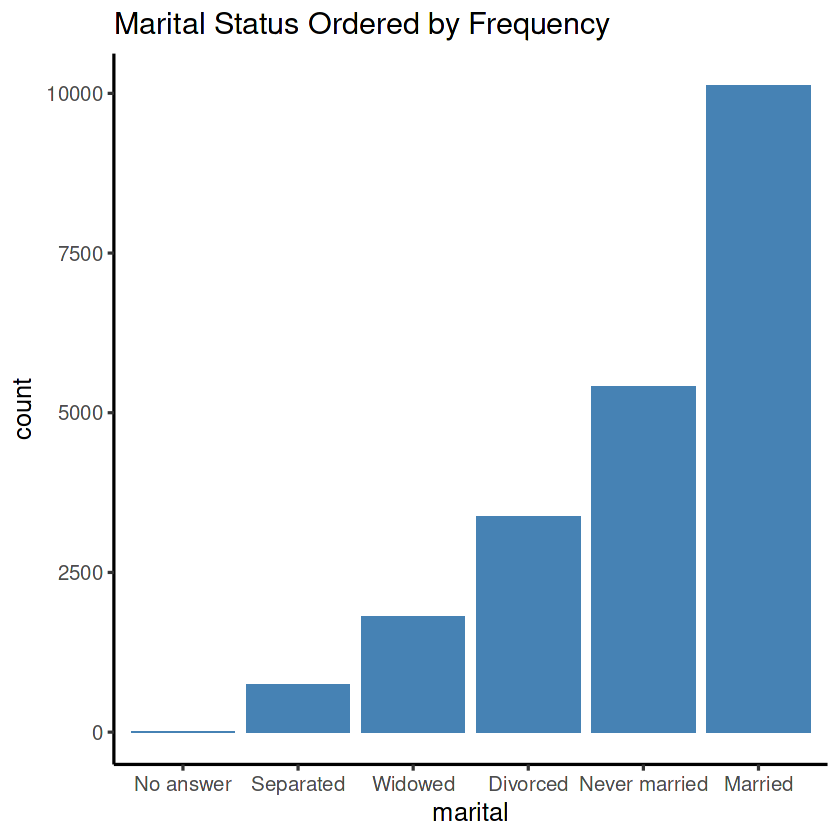

In [ ]:
gss_cat %>%
  mutate(marital = fct_infreq(marital)) %>% # সবচেয়ে ঘন ঘন আসা ক্যাটাগরি আগে
  mutate(marital = fct_rev(marital)) %>%    # ক্রমটি উল্টে দেওয়া (Reverse)
  ggplot(aes(marital)) +
  geom_bar(fill = "steelblue") +
  theme_classic(base_size = 15) +
  labs(title = "Marital Status Ordered by Frequency")

### **৪. অন্য ভ্যারিয়েবল অনুযায়ী সাজানো (`fct_reorder`)**

এটি ভিজ্যুয়ালাইজেশনের জন্য সবচেয়ে শক্তিশালী টুল। যেমন—কোন ধর্মের মানুষ গড়ে কতটুকু টিভি দেখে, তা ক্রমানুসারে সাজানো।

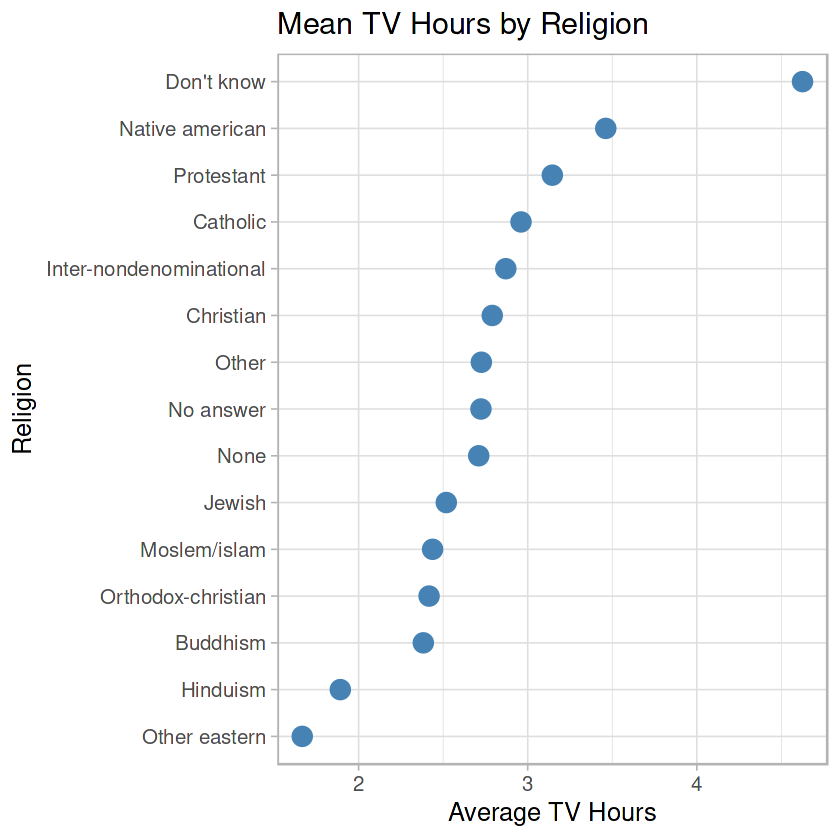

In [ ]:
gss_cat %>%
  group_by(relig) %>%
  summarise(TV_watchtime_mean = mean(tvhours, na.rm = TRUE)) %>%
  mutate(relig = fct_reorder(relig, TV_watchtime_mean)) %>% # টিভি দেখার গড় সময় অনুযায়ী সাজানো
  ggplot(aes(TV_watchtime_mean, relig)) +
  geom_point(size = 5, color = "steelblue") +
  theme_light(base_size = 15) +
  labs(title = "Mean TV Hours by Religion",
       x = "Average TV Hours", y = "Religion")

### **৫. লেভেল রিনেম এবং মার্জ করা (Recode & Collapse)**

ডেটা ক্লিনিংয়ের সময় অনেক সময় ছোট ছোট কয়েকটি ক্যাটাগরিকে একটি বড় ক্যাটাগরিতে আনার প্রয়োজন হয়।

#### **ক) লেভেল রিকোড করা (`fct_recode`)**

In [ ]:
gss_cat %>%
  mutate(partyid = fct_recode(partyid,
                              "others" = "Other party",
                              "others" = "No answer",
                              "others" = "Don't know",
                              "Not Strong republican" = "Not str republican",
                              "Slightly republican" = "Ind,near rep",
                              "Slightly democrat" = "Ind,near dem",
                              "Not Strong democrat" = "Not str democrat")) %>%
  count(partyid)

partyid,n
<fct>,<int>
others,548
Strong republican,2314
Not Strong republican,3032
Slightly republican,1791
Independent,4119
Slightly democrat,2499
Not Strong democrat,3690
Strong democrat,3490


#### **খ) লেভেল কোলাপস করা (`fct_collapse`)**

অনেকগুলো লেভেলকে একসাথে একটি গ্রুপে আনার সহজ উপায়:

In [ ]:
gss_cat %>%
  mutate(partyid = fct_collapse(partyid,
                                "others" = c("Other party", "No answer", "Don't know"),
                                "Republican" = c("Not str republican", "Strong republican"),
                                "Democrat" = c("Strong democrat", "Not str democrat"),
                                "Independent" = c("Ind,near dem", "Ind,near rep"))) %>%
  count(partyid)

partyid,n
<fct>,<int>
others,548
Republican,5346
Independent,8409
Democrat,7180


### **এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):**

* **`fct_drop()`**: অব্যবহৃত লেভেল ডিলিট করার জন্য।
* **`fct_relevel()`**: নিজের পছন্দমতো ক্রম সেট করার জন্য।
* **`fct_infreq()`**: সংখ্যা বা গণনার ভিত্তিতে বড় থেকে ছোট সাজাতে।
* **`fct_reorder()`**: একটি নিউমেরিক কলামের ভ্যালু অনুযায়ী ক্যাটাগরি সাজাতে।
* **`fct_collapse()`**: গ্রুপ তৈরির মাধ্যমে ক্যাটাগরি সংখ্যা কমাতে।

---

**দুর্দান্ত!** আপনি এখন ক্যাটাগরিক্যাল ডেটা ক্লিনিং এবং সাজানোর সবকটি প্রো-লেভেল টেকনিক জানেন।